W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 26.6 MB/s eta 0:00:00


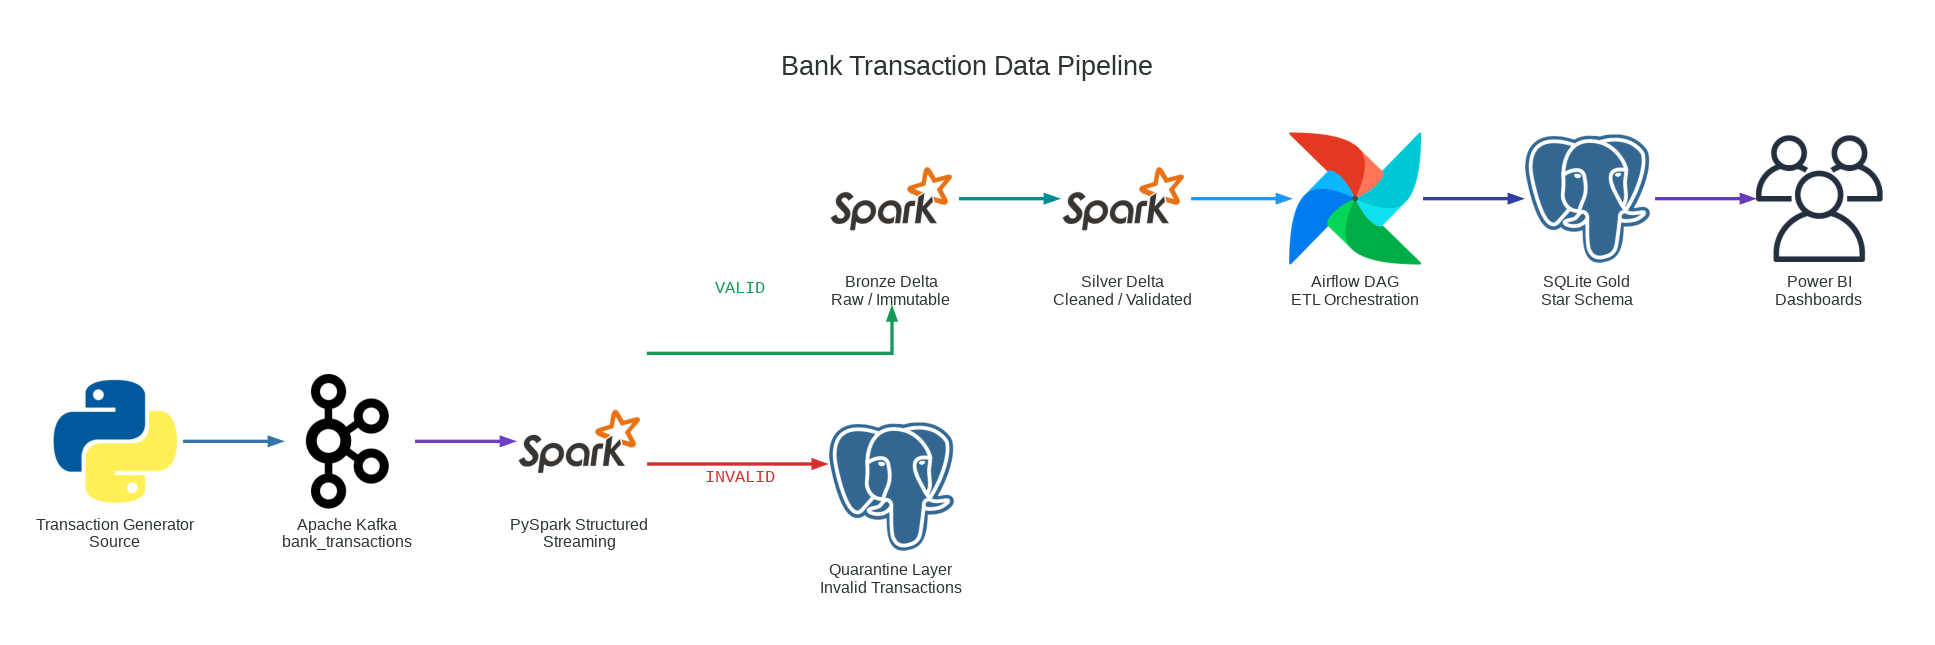

In [3]:
# ============================================================
# BANK TRANSACTION DATA PIPELINE
# Professional Architecture Diagram with Technology Icons
# ============================================================

# Install required packages
!apt-get -qq update
!apt-get -qq install graphviz
!pip install -q diagrams

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

from diagrams import Diagram, Cluster, Edge
from diagrams.programming.language import Python

from diagrams.onprem.queue import Kafka
from diagrams.onprem.analytics import Spark
from diagrams.onprem.workflow import Airflow
from diagrams.onprem.database import PostgreSQL
from diagrams.onprem.client import Users

from IPython.display import Image, display


# ============================================================
# DIAGRAM
# ============================================================

with Diagram(
    "Bank Transaction Data Pipeline",
    filename="Bank_Transaction_Architecture",
    show=False,
    direction="LR",
    graph_attr={
        "bgcolor": "white",
        "pad": "0.5",
        "nodesep": "0.7",
        "ranksep": "1.0",
        "splines": "ortho",
        "fontname": "Arial",
        "fontsize": "20",
        "label": "Bank Transaction Data Pipeline",
        "labelloc": "t",
        "labeljust": "c"
    },
    node_attr={
        "fontname": "Arial",
        "fontsize": "12",
        "margin": "0.2"
    },
    edge_attr={
        "color": "#555555",
        "penwidth": "1.8",
        "arrowsize": "0.8"
    }
):

    # ========================================================
    # SOURCE
    # ========================================================

    python = Python(
        "Transaction Generator\n"
        "Source"
    )

    # ========================================================
    # KAFKA
    # ========================================================

    kafka = Kafka(
        "Apache Kafka\n"
        "bank_transactions"
    )

    # ========================================================
    # PYSPARK STREAMING
    # ========================================================

    spark = Spark(
        "PySpark Structured\n"
        "Streaming"
    )

    # ========================================================
    # VALID DATA
    # ========================================================

    bronze = Spark(
        "Bronze Delta\n"
        "Raw / Immutable"
    )

    silver = Spark(
        "Silver Delta\n"
        "Cleaned / Validated"
    )

    # ========================================================
    # ORCHESTRATION
    # ========================================================

    airflow = Airflow(
        "Airflow DAG\n"
        "ETL Orchestration"
    )

    # ========================================================
    # GOLD DATABASE
    # ========================================================

    gold = PostgreSQL(
        "SQLite Gold\n"
        "Star Schema"
    )

    # ========================================================
    # POWER BI
    # ========================================================

    powerbi = Users(
        "Power BI\n"
        "Dashboards"
    )

    # ========================================================
    # QUARANTINE
    # ========================================================

    quarantine = PostgreSQL(
        "Quarantine Layer\n"
        "Invalid Transactions"
    )

    # ========================================================
    # MAIN FLOW
    # ========================================================

    python >> Edge(
        color="#3776AB",
        penwidth="2.5"
    ) >> kafka

    kafka >> Edge(
        color="#6C3FC5",
        penwidth="2.5"
    ) >> spark

    # ========================================================
    # VALID / INVALID BRANCH
    # ========================================================

    spark >> Edge(
        label=" VALID",
        color="#159957",
        fontcolor="#159957",
        penwidth="2.5"
    ) >> bronze

    spark >> Edge(
        label=" INVALID",
        color="#D32F2F",
        fontcolor="#D32F2F",
        penwidth="2.5"
    ) >> quarantine

    # ========================================================
    # VALID PIPELINE
    # ========================================================

    bronze >> Edge(
        color="#008C95",
        penwidth="2.5"
    ) >> silver

    silver >> Edge(
        color="#2196F3",
        penwidth="2.5"
    ) >> airflow

    airflow >> Edge(
        color="#303F9F",
        penwidth="2.5"
    ) >> gold

    gold >> Edge(
        color="#673AB7",
        penwidth="2.5"
    ) >> powerbi


# ============================================================
# DISPLAY
# ============================================================

display(
    Image(
        filename="Bank_Transaction_Architecture.png"
    )
)